# Credit-Risk PD Modeling with MLflow — 3 Experiments, Compared

A banking-grade walkthrough that trains **Probability-of-Default (PD)** models under **three distinct MLflow experiments**, each representing a different modeling *strategy*, then compares them **across experiments** and registers the winner. This mirrors how a model-development team actually works: several competing approaches, one shared scoreboard, a governed promotion decision.

### The three experiments

| Experiment | Strategy | Why a bank cares |
|---|---|---|
| `credit_default_linear` | Regularized **logistic regression** (L1/L2) | Interpretable, monotonic, regulator-friendly — the scorecard tradition |
| `credit_default_trees` | **Tree ensembles** (RF, HistGBDT, XGBoost) | Capture nonlinearities & interactions in applicant behavior |
| `credit_default_xgb_tuned` | **Optuna-tuned, imbalance-aware XGBoost** | Squeeze out performance with class-weighting + HPO |

### Credit-risk metrics (not just accuracy)
- **AUC / Gini** — rank-ordering power (`Gini = 2·AUC − 1`); Gini is the standard headline in credit scoring.
- **KS statistic** — maximum separation between good/bad score distributions; the classic discrimination metric.
- **Brier score** — calibration quality; PDs feed pricing & capital, so they must be *calibrated*, not just ranked.
- **Cost-sensitive threshold** — a missed default (FN) costs far more than a declined good customer (FP); we pick the operating point that minimizes expected loss.

> **Data:** a realistic *synthetic* credit portfolio (12k applicants, ~13% default) so the notebook runs offline and deterministically. A one-line swap to the real UCI/OpenML *Default of Credit Card Clients* dataset is included.

## 0. Install

In [1]:
# %pip install -q mlflow scikit-learn xgboost optuna shap matplotlib pandas
import mlflow; print("MLflow", mlflow.__version__)

MLflow 3.12.0


## 1. Imports & reproducibility

In [2]:
import warnings, os; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import mlflow
from mlflow import MlflowClient
from mlflow.models import infer_signature, evaluate
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss, recall_score
import xgboost as xgb
import optuna

SEED = 42; np.random.seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

## 2. Tracking & registry store
A SQLite backend so the **Model Registry** works. Swap these URIs for Postgres + S3/MinIO in production — nothing else changes.

In [3]:
ROOT = os.path.abspath("./mlruns_credit"); os.makedirs(ROOT, exist_ok=True)
mlflow.set_tracking_uri(f"sqlite:///{ROOT}/mlflow.db")

EXP_LINEAR = "credit_default_linear"
EXP_TREES  = "credit_default_trees"
EXP_TUNED  = "credit_default_xgb_tuned"
ALL_EXPERIMENTS = [EXP_LINEAR, EXP_TREES, EXP_TUNED]

print("Tracking URI:", mlflow.get_tracking_uri())
print("UI:  mlflow ui --backend-store-uri sqlite:///%s/mlflow.db" % ROOT)

Tracking URI: sqlite:////home/claude/mlruns_credit/mlflow.db
UI:  mlflow ui --backend-store-uri sqlite:////home/claude/mlruns_credit/mlflow.db


## 3. The credit portfolio (synthetic, realistic)

Twelve features spanning the kind of bureau + application data a lender sees. The target is generated from a latent default process that is **mostly linear but with deliberate interactions and nonlinearities** — a compounding high-utilization × high-DTI segment, a sub-prime credit-score cliff, accelerating delinquency risk — so tree/boosting models have real structure to exploit beyond what a plain linear model captures.

> **Use real data instead:** uncomment the OpenML loader to pull the UCI *Default of Credit Card Clients* dataset (30k rows, Taiwan) and skip the synthetic generator.

In [4]:
def make_credit_data(n=12000, seed=SEED):
    rng = np.random.default_rng(seed)
    age      = rng.normal(40, 11, n).clip(21, 75)
    income   = np.exp(rng.normal(10.9, 0.5, n)).clip(15000, 400000)
    emp_len  = rng.gamma(2.0, 3.0, n).clip(0, 40)
    dti      = (rng.beta(2, 5, n) * 60).clip(0, 80)
    util     = rng.beta(2, 3, n).clip(0, 1)
    n_lines  = rng.poisson(8, n).clip(1, 40)
    late     = rng.poisson(0.6, n).clip(0, 15)
    loan_amt = (income * rng.uniform(0.05, 0.6, n)).clip(1000, 150000)
    term     = rng.choice([36, 60], n, p=[0.7, 0.3])
    home     = rng.choice(["RENT", "OWN", "MORTGAGE"], n, p=[0.45, 0.15, 0.40])
    purpose  = rng.choice(["debt_consolidation","credit_card","home_improvement",
                           "major_purchase","small_business"], n, p=[0.4,0.25,0.15,0.12,0.08])
    cscore   = (720 - 0.9*dti - 120*util - 25*late + 0.0002*income
                + rng.normal(0, 30, n)).clip(300, 850)
    # latent default logit: linear main effects + interactions + nonlinearities
    z = (-3.2 + 0.020*dti + 0.9*util + 0.12*late - 0.000006*income
         - 0.005*(cscore-650) + 0.010*(loan_amt/1000)/(income/50000)
         + 0.3*(home=="RENT") + 0.4*(purpose=="small_business") - 0.012*emp_len
         + 2.4*((util>0.7) & (dti>40))            # compounding high-risk segment
         + 1.3*(cscore<580)                        # sub-prime cliff
         + 0.9*((cscore<620) & (late>=2))          # near-prime + delinquency
         + 0.05*late*late                          # accelerating delinquency
         + 0.7*((purpose=="small_business") & (emp_len<3))
         + 1.0*((home=="RENT") & (util>0.6))       # renter + high utilization
         + rng.normal(0, 0.40, n))
    p = 1/(1+np.exp(-z)); y = (rng.uniform(size=n) < p).astype(int)
    df = pd.DataFrame(dict(age=age, annual_income=income, employment_length=emp_len,
        debt_to_income=dti, credit_utilization=util, num_credit_lines=n_lines,
        num_late_payments_2yr=late, loan_amount=loan_amt, loan_term=term.astype(str),
        home_ownership=home, purpose=purpose, credit_score=cscore))
    return df, pd.Series(y, name="default")

X, y = make_credit_data()

# ---- OPTION: real data instead of synthetic ----
# from sklearn.datasets import fetch_openml
# raw = fetch_openml("default-of-credit-card-clients", version=1, as_frame=True)
# X, y = raw.data, raw.target.astype(int)

print(f"applicants={len(X)}  features={X.shape[1]}  default_rate={y.mean():.3f}")
X.head()

applicants=12000  features=12  default_rate=0.130


,age,annual_income,employment_length,debt_to_income,credit_utilization,num_credit_lines,num_late_payments_2yr,loan_amount,loan_term,home_ownership,purpose,credit_score
0,43.351888,46402.388728,3.535681,16.163108,0.285612,9,0,8948.030402,36,RENT,credit_card,654.617436
1,28.560175,55832.872425,3.504569,33.952374,0.410396,9,0,4479.212061,60,OWN,credit_card,628.754339
2,48.254963,29132.860065,4.529867,9.180054,0.414183,4,1,17145.682798,36,RENT,credit_card,623.315938
3,50.346212,27068.425561,5.369055,15.957444,0.138752,12,1,4136.196451,36,MORTGAGE,credit_card,695.804143
4,21.000000,59346.527600,1.589655,10.971132,0.082088,8,2,31505.902686,36,MORTGAGE,credit_card,718.887989


## 4. Splits & preprocessing

In [5]:
NUM = ["age","annual_income","employment_length","debt_to_income","credit_utilization",
       "num_credit_lines","num_late_payments_2yr","loan_amount","credit_score"]
CAT = ["loan_term","home_ownership","purpose"]

# 60 / 20 / 20 stratified — preserves the rare-default base rate in every split
X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.25,
                                                  stratify=y_tmp, random_state=SEED)
print(f"train={len(X_train)}  val={len(X_val)}  test={len(X_test)}")

def make_pre(scale):
    # scale=True for linear models (coefficients need standardized inputs);
    # scale=False for trees (scale-invariant). Categoricals are one-hot encoded either way.
    num = StandardScaler() if scale else "passthrough"
    return ColumnTransformer([("num", num, NUM),
                              ("cat", OneHotEncoder(handle_unknown="ignore"), CAT)])

SCALE_POS_WEIGHT = float((y_train==0).sum() / (y_train==1).sum())  # imbalance ratio for XGB
print(f"scale_pos_weight (neg/pos) = {SCALE_POS_WEIGHT:.2f}")

train=7200  val=2400  test=2400
scale_pos_weight (neg/pos) = 6.67


## 5. Credit-risk metric helpers

Banking discrimination/calibration metrics plus a **cost-optimal threshold**: we assume a false negative (funding a defaulter) costs 5× a false positive (declining a good applicant), and pick the cutoff that minimizes total cost on the *validation* set.

In [6]:
def ks_gini_auc(y_true, score):
    fpr, tpr, _ = roc_curve(y_true, score)
    auc = roc_auc_score(y_true, score)
    ks  = float(np.max(tpr - fpr))     # Kolmogorov-Smirnov separation
    return ks, float(2*auc - 1), float(auc)   # KS, Gini, AUC

def best_cost_threshold(y_true, score, c_fn=5, c_fp=1):
    best_t, best_cost = 0.5, np.inf
    for t in np.linspace(0.05, 0.95, 19):
        pred = (score >= t).astype(int)
        fn = int(((pred==0) & (y_true==1)).sum())
        fp = int(((pred==1) & (y_true==0)).sum())
        cost = c_fn*fn + c_fp*fp
        if cost < best_cost: best_t, best_cost = float(t), float(cost)
    return best_t, best_cost

## 6. One reusable logging routine

Every run — regardless of experiment — is fit on **train**, selected on **validation**, and reported on **test**, logging the full credit-risk metric set plus a serving-ready model (signature + input example). It returns a summary row we collect for the cross-experiment comparison.

In [7]:
RESULTS = []   # collected across all experiments

def log_run(experiment, run_name, pipe, params):
    mlflow.set_experiment(experiment)
    with mlflow.start_run(run_name=run_name) as r:
        pipe.fit(X_train, y_train)
        v = pipe.predict_proba(X_val)[:, 1]
        t = pipe.predict_proba(X_test)[:, 1]
        v_ks, v_gini, v_auc = ks_gini_auc(y_val, v)
        t_ks, t_gini, t_auc = ks_gini_auc(y_test, t)
        thr, _ = best_cost_threshold(y_val.values, v)
        t_recall = recall_score(y_test, (t >= thr).astype(int))

        mlflow.log_params(params)
        mlflow.log_metrics(dict(
            val_auc=v_auc, val_ks=v_ks, val_gini=v_gini, val_brier=brier_score_loss(y_val, v),
            test_auc=t_auc, test_ks=t_ks, test_gini=t_gini,
            opt_threshold=thr, test_recall_at_thr=t_recall))
        sig = infer_signature(X_val, pipe.predict(X_val))
        mlflow.sklearn.log_model(pipe, name="model", signature=sig, input_example=X_val.iloc[:3])

        row = dict(experiment=experiment, run=run_name, val_auc=v_auc, test_auc=t_auc,
                   test_ks=t_ks, test_gini=t_gini, run_id=r.info.run_id,
                   model_uri=f"runs:/{r.info.run_id}/model")
        RESULTS.append(row)
        print(f"  {run_name:18s} val_auc={v_auc:.4f}  test_auc={t_auc:.4f}  KS={t_ks:.3f}  Gini={t_gini:.3f}")
        return row

## 7. Experiment 1 — Linear / interpretable (the scorecard tradition)

Regularized logistic regression with `class_weight="balanced"` to handle the rare-default class. Three runs: L2, L1 (sparse, drops weak features), and a heavily-regularized L2. These are the models a model-risk committee finds easiest to validate.

In [8]:
print(EXP_LINEAR)
for name, penalty, C in [("logreg_l2","l2",1.0), ("logreg_l1","l1",0.5), ("logreg_l2_strong","l2",0.05)]:
    solver = "liblinear" if penalty=="l1" else "lbfgs"
    pipe = Pipeline([("pre", make_pre(scale=True)),
                     ("clf", LogisticRegression(penalty=penalty, C=C, solver=solver,
                                                max_iter=2000, class_weight="balanced",
                                                random_state=SEED))])
    log_run(EXP_LINEAR, name, pipe, dict(model="logreg", penalty=penalty, C=C,
                                         class_weight="balanced"))

credit_default_linear


2026/05/30 09:47:39 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/05/30 09:47:39 INFO mlflow.store.db.utils: Updating database tables


2026/05/30 09:47:40 INFO mlflow.tracking.fluent: Experiment with name 'credit_default_linear' does not exist. Creating a new experiment.


2026/05/30 09:47:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  logreg_l2          val_auc=0.7442  test_auc=0.7457  KS=0.357  Gini=0.491


2026/05/30 09:47:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/05/30 09:47:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  logreg_l1          val_auc=0.7440  test_auc=0.7454  KS=0.355  Gini=0.491


  logreg_l2_strong   val_auc=0.7437  test_auc=0.7456  KS=0.356  Gini=0.491


## 8. Experiment 2 — Tree ensembles

Random Forest, HistGradientBoosting (sklearn's fast boosting), and a default-settings XGBoost with `scale_pos_weight` for imbalance. These pick up the interactions baked into the data that the linear model can only approximate.

In [9]:
print(EXP_TREES)
log_run(EXP_TREES, "random_forest",
    Pipeline([("pre", make_pre(scale=False)),
              ("clf", RandomForestClassifier(n_estimators=300, max_depth=8,
                        class_weight="balanced", n_jobs=-1, random_state=SEED))]),
    dict(model="random_forest", n_estimators=300, max_depth=8))

log_run(EXP_TREES, "hist_gbdt",
    Pipeline([("pre", make_pre(scale=False)),
              ("clf", HistGradientBoostingClassifier(max_depth=4, learning_rate=0.08,
                        max_iter=300, random_state=SEED))]),
    dict(model="hist_gbdt", max_depth=4, learning_rate=0.08, max_iter=300))

log_run(EXP_TREES, "xgboost_default",
    Pipeline([("pre", make_pre(scale=False)),
              ("clf", xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.08,
                        scale_pos_weight=SCALE_POS_WEIGHT, eval_metric="logloss",
                        random_state=SEED))]),
    dict(model="xgboost", n_estimators=300, max_depth=4, scale_pos_weight=round(SCALE_POS_WEIGHT,3)))

2026/05/30 09:47:51 INFO mlflow.tracking.fluent: Experiment with name 'credit_default_trees' does not exist. Creating a new experiment.


credit_default_trees


2026/05/30 09:47:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  random_forest      val_auc=0.7532  test_auc=0.7390  KS=0.378  Gini=0.478


2026/05/30 09:47:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  hist_gbdt          val_auc=0.7521  test_auc=0.7316  KS=0.377  Gini=0.463


2026/05/30 09:48:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  xgboost_default    val_auc=0.7332  test_auc=0.7273  KS=0.365  Gini=0.455


{'experiment': 'credit_default_trees',
 'run': 'xgboost_default',
 'val_auc': 0.7331832077779531,
 'test_auc': 0.7273047359969138,
 'test_ks': 0.3647224335648491,
 'test_gini': 0.4546094719938276,
 'run_id': '08bca600822d4ab1acee2b3168a7e176',
 'model_uri': 'runs:/08bca600822d4ab1acee2b3168a7e176/model'}

## 9. Experiment 3 — Optuna-tuned, imbalance-aware XGBoost

A proper hyperparameter search where each trial is a **nested run** under one parent. We also tune `scale_pos_weight` itself, letting the search decide how aggressively to up-weight defaults. Trials are scored on **validation**.

In [10]:
mlflow.set_experiment(EXP_TUNED)

def objective(trial):
    params = dict(
        max_depth        = trial.suggest_int("max_depth", 2, 7),
        learning_rate    = trial.suggest_float("learning_rate", 1e-2, 0.3, log=True),
        n_estimators     = trial.suggest_int("n_estimators", 100, 500),
        subsample        = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_lambda       = trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        scale_pos_weight = trial.suggest_float("scale_pos_weight", 1.0, SCALE_POS_WEIGHT*1.5),
    )
    with mlflow.start_run(nested=True, run_name=f"trial_{trial.number}"):
        pipe = Pipeline([("pre", make_pre(scale=False)),
                         ("clf", xgb.XGBClassifier(**params, eval_metric="logloss",
                                                   random_state=SEED))])
        pipe.fit(X_train, y_train)
        _, _, auc = ks_gini_auc(y_val, pipe.predict_proba(X_val)[:, 1])
        mlflow.log_params(params); mlflow.log_metric("val_auc", auc)
    return auc

with mlflow.start_run(run_name="xgb_optuna_parent"):
    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=15)
    BEST = study.best_params
    mlflow.log_metric("best_val_auc", study.best_value)
    mlflow.log_params({f"best_{k}": v for k, v in BEST.items()})
    print(f"best val_auc = {study.best_value:.4f}")

# log the tuned winner as a standalone, comparable run in this experiment
print(EXP_TUNED)
log_run(EXP_TUNED, "xgb_best",
    Pipeline([("pre", make_pre(scale=False)),
              ("clf", xgb.XGBClassifier(**BEST, eval_metric="logloss", random_state=SEED))]),
    dict(model="xgboost_tuned", **{k: round(v,4) if isinstance(v,float) else v
                                    for k,v in BEST.items()}))

2026/05/30 09:48:06 INFO mlflow.tracking.fluent: Experiment with name 'credit_default_xgb_tuned' does not exist. Creating a new experiment.


best val_auc = 0.7607
credit_default_xgb_tuned


2026/05/30 09:48:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  xgb_best           val_auc=0.7607  test_auc=0.7553  KS=0.407  Gini=0.511


{'experiment': 'credit_default_xgb_tuned',
 'run': 'xgb_best',
 'val_auc': 0.7606910878387584,
 'test_auc': 0.7552910073159418,
 'test_ks': 0.4065851130763849,
 'test_gini': 0.5105820146318836,
 'run_id': '04a0ffb74fad470e96e8c674fa162ba4',
 'model_uri': 'runs:/04a0ffb74fad470e96e8c674fa162ba4/model'}

## 10. Cross-experiment comparison

`mlflow.search_runs` pulls runs from **all three experiments** into one DataFrame — the shared scoreboard. We rank everything, then reduce to the best run per experiment.

In [11]:
combined = mlflow.search_runs(experiment_names=ALL_EXPERIMENTS,
                              order_by=["metrics.val_auc DESC"])
cols = ["tags.mlflow.runName","metrics.val_auc","metrics.test_auc",
        "metrics.test_ks","metrics.test_gini"]
cols = [c for c in cols if c in combined.columns]
print("Top runs across ALL experiments:")
display(combined[combined["tags.mlflow.runName"].notna()][cols].head(10))

res = pd.DataFrame(RESULTS)
best_per = (res.sort_values("val_auc", ascending=False)
               .groupby("experiment", as_index=False).first())
print("\nBest run per experiment (selected on validation):")
display(best_per[["experiment","run","val_auc","test_auc","test_ks","test_gini"]])

Top runs across ALL experiments:


,tags.mlflow.runName,metrics.val_auc,metrics.test_auc,metrics.test_ks,metrics.test_gini
0,xgb_best,0.760691,0.755291,0.406585,0.510582
1,trial_3,0.760691,NaN,NaN,NaN
2,trial_14,0.760018,NaN,NaN,NaN
3,trial_12,0.759547,NaN,NaN,NaN
4,trial_2,0.759215,NaN,NaN,NaN
5,trial_11,0.755289,NaN,NaN,NaN
6,trial_4,0.753383,NaN,NaN,NaN
7,random_forest,0.753193,0.739020,0.377831,0.478041
8,hist_gbdt,0.752146,0.731576,0.376545,0.463152
9,trial_13,0.751494,NaN,NaN,NaN



Best run per experiment (selected on validation):


,experiment,run,val_auc,test_auc,test_ks,test_gini
0,credit_default_linear,logreg_l2,0.744201,0.745655,0.357223,0.491310
1,credit_default_trees,random_forest,0.753193,0.739020,0.377831,0.478041
2,credit_default_xgb_tuned,xgb_best,0.760691,0.755291,0.406585,0.510582


### Visual comparison of the three strategies

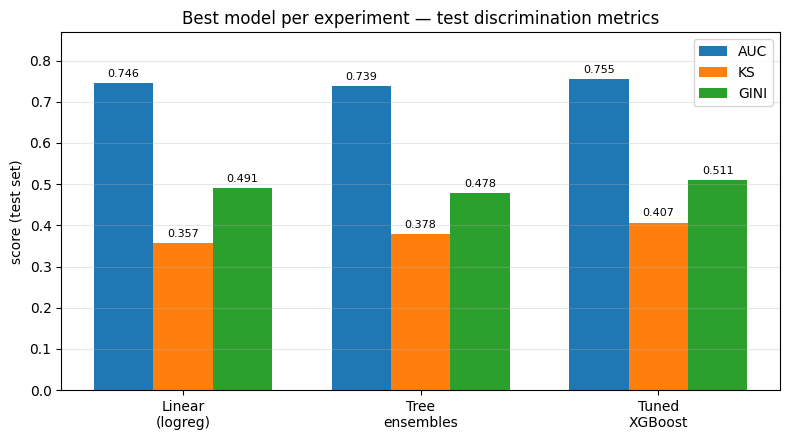

In [12]:
metrics = ["test_auc", "test_ks", "test_gini"]
labels  = {"credit_default_linear":"Linear\n(logreg)",
           "credit_default_trees":"Tree\nensembles",
           "credit_default_xgb_tuned":"Tuned\nXGBoost"}
order = best_per.set_index("experiment").loc[
    [e for e in ALL_EXPERIMENTS if e in best_per.experiment.values]]

x = np.arange(len(order)); w = 0.25
fig, ax = plt.subplots(figsize=(8, 4.5))
for i, m in enumerate(metrics):
    ax.bar(x + (i-1)*w, order[m].values, w, label=m.replace("test_","").upper())
ax.set_xticks(x); ax.set_xticklabels([labels[e] for e in order.index])
ax.set_ylabel("score (test set)"); ax.set_ylim(0, max(0.8, order[metrics].values.max()*1.15))
ax.set_title("Best model per experiment — test discrimination metrics")
ax.legend(); ax.grid(axis="y", alpha=0.3)
for i, m in enumerate(metrics):
    for j, v in enumerate(order[m].values):
        ax.text(j+(i-1)*w, v+0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

## 11. Evaluate the overall winner on the held-out test set

We take the single best run (by validation AUC) and run `mlflow.models.evaluate`, which logs the classifier diagnostic suite — ROC, precision-recall, lift, calibration, and confusion matrix. (The auto SHAP explainer skips preprocessing-pipeline models, so we add SHAP attributions explicitly in the next cell.)

In [13]:
winner = res.sort_values("val_auc", ascending=False).iloc[0]
print(f"Winner: {winner['experiment']} / {winner['run']}  (val_auc={winner['val_auc']:.4f})")

eval_df = X_test.copy(); eval_df["default"] = y_test.values
mlflow.set_experiment("credit_default_FINAL")
with mlflow.start_run(run_name="evaluate_winner"):
    result = evaluate(winner["model_uri"], data=eval_df, targets="default",
                      model_type="classifier", evaluators=["default"],
                      evaluator_config={"default": {"explainability_nsamples": 100}})
    for k in ["roc_auc","accuracy_score","precision_score","recall_score","f1_score","log_loss"]:
        if k in result.metrics: print(f"  {k:16s} {result.metrics[k]:.4f}")
    print("artifacts:", list(result.artifacts.keys()))

2026/05/30 09:48:16 INFO mlflow.tracking.fluent: Experiment with name 'credit_default_FINAL' does not exist. Creating a new experiment.


Winner: credit_default_xgb_tuned / xgb_best  (val_auc=0.7607)


2026/05/30 09:48:16 WARNING mlflow.models.evaluation.evaluators.classifier: According to the evaluation dataset label values, the model type looks like None, but you specified model type 'classifier'. Please verify that you set the `model_type` and `dataset` arguments correctly.


2026/05/30 09:48:16 INFO mlflow.models.evaluation.evaluators.classifier: The evaluation dataset is inferred as binary dataset, positive label is 1, negative label is 0.


2026/05/30 09:48:16 INFO mlflow.models.evaluation.default_evaluator: Testing metrics on first row...


2026/05/30 09:48:18 WARNING mlflow.models.evaluation.evaluators.shap: Skip logging model explainability insights because the shap explainer None requires all feature values to be numeric, and each feature column must only contain scalar values.


  roc_auc          0.7553
  accuracy_score   0.7963
  precision_score  0.3247
  recall_score     0.5208
  f1_score         0.4000
  log_loss         0.5141
artifacts: ['roc_curve_plot', 'precision_recall_curve_plot', 'lift_curve_plot', 'calibration_curve_plot', 'confusion_matrix']


<Figure size 1050x700 with 0 Axes>

## 11b. SHAP explainability for model governance

For adverse-action reasoning and model-risk review, we explain the **XGBoost component** directly. We pull the fitted preprocessor and classifier out of the winning pipeline, transform the test set to the model's actual feature space, and compute SHAP values — logging the summary plot as an artifact.

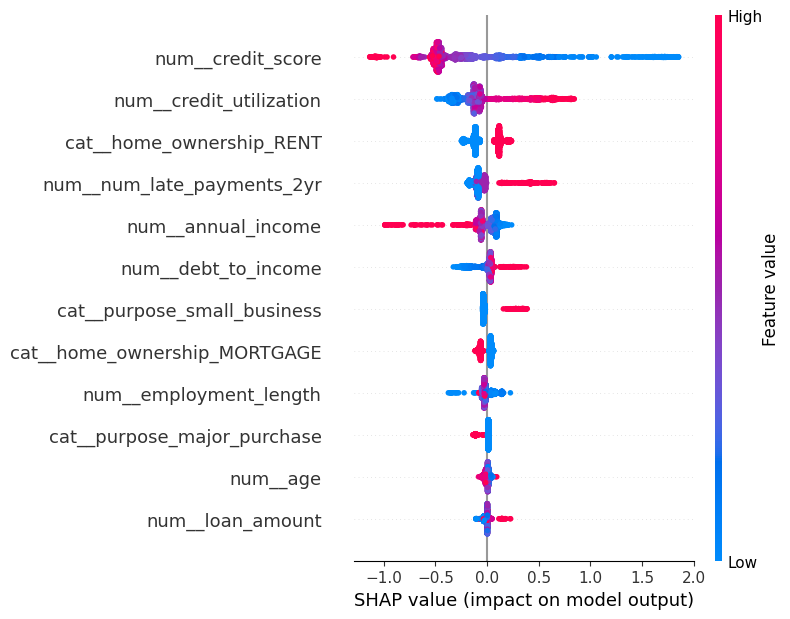

Top global PD drivers:


,feature,mean_abs_shap
0,num__credit_score,0.469659
1,num__credit_utilization,0.227689
2,cat__home_ownership_RENT,0.131677
3,num__num_late_payments_2yr,0.116952
4,num__annual_income,0.094532
5,num__debt_to_income,0.066356
6,cat__purpose_small_business,0.056415
7,cat__home_ownership_MORTGAGE,0.052558


In [14]:
import shap
win_pipe = mlflow.sklearn.load_model(winner["model_uri"])
pre_fitted = win_pipe.named_steps["pre"]
clf_fitted = win_pipe.named_steps["clf"]

Xt = pre_fitted.transform(X_test)
feat_names = list(pre_fitted.get_feature_names_out())

explainer = shap.TreeExplainer(clf_fitted)
shap_values = explainer.shap_values(Xt)

with mlflow.start_run(run_name="shap_explanations"):
    fig = plt.figure()
    shap.summary_plot(shap_values, Xt, feature_names=feat_names, show=False, max_display=12)
    plt.tight_layout()
    mlflow.log_figure(plt.gcf(), "plots/shap_summary.png")
    plt.show()

# top global drivers of predicted default risk
import numpy as np
imp = pd.DataFrame({"feature": feat_names,
                    "mean_abs_shap": np.abs(shap_values).mean(axis=0)})
print("Top global PD drivers:")
display(imp.sort_values("mean_abs_shap", ascending=False).head(8).reset_index(drop=True))

## 12. Register the winner & promote to champion

The winning model is registered, tagged with **which experiment produced it** (audit trail), and aliased `@champion`.

In [15]:
client = MlflowClient()
REGISTERED = "pd_credit_default"
mv = mlflow.register_model(winner["model_uri"], REGISTERED)
client.set_registered_model_alias(REGISTERED, "champion", mv.version)
client.set_model_version_tag(REGISTERED, mv.version, "winning_experiment", winner["experiment"])
client.set_model_version_tag(REGISTERED, mv.version, "test_gini", f"{winner['test_gini']:.4f}")
print(f"Registered '{REGISTERED}' v{mv.version}  ->  @champion  (from {winner['experiment']})")

for v in client.search_model_versions(f"name='{REGISTERED}'"):
    print(f"  v{v.version}  aliases={v.aliases}  tags={v.tags}")

Successfully registered model 'pd_credit_default'.
2026/05/30 09:48:27 WARNING mlflow.tracking._model_registry.fluent: Run with id 04a0ffb74fad470e96e8c674fa162ba4 has no artifacts at artifact path 'model', registering model based on models:/m-b8bd36fe20064d82982046e36c812073 instead


Registered 'pd_credit_default' v1  ->  @champion  (from credit_default_xgb_tuned)
  v1  aliases=[]  tags={'winning_experiment': 'credit_default_xgb_tuned', 'test_gini': '0.5106'}


Created version '1' of model 'pd_credit_default'.


## 13. Score new loan applications (PD + decision)

Load the champion by alias and produce a PD for incoming applicants. We apply the **cost-optimal threshold** to turn the probability into an approve/decline decision — the operating point that minimized expected loss on validation.

In [16]:
champion = mlflow.pyfunc.load_model(f"models:/{REGISTERED}@champion")

# cost-optimal cutoff recomputed on validation (same logic used during selection)
v_scores = mlflow.sklearn.load_model(winner["model_uri"]).predict_proba(X_val)[:, 1]
THRESHOLD, _ = best_cost_threshold(y_val.values, v_scores)

applicants = X_test.iloc[:8].copy()
pd_scores  = np.asarray(champion.predict(applicants))           # pyfunc -> class label
proba      = mlflow.sklearn.load_model(winner["model_uri"]).predict_proba(applicants)[:, 1]

decision = pd.DataFrame({
    "PD": np.round(proba, 4),
    "threshold": THRESHOLD,
    "decision": np.where(proba >= THRESHOLD, "DECLINE", "APPROVE"),
    "credit_score": applicants["credit_score"].round().astype(int).values,
    "DTI": applicants["debt_to_income"].round(1).values,
    "utilization": applicants["credit_utilization"].round(2).values,
})
print(f"Decision cutoff (cost-optimal, FN=5×FP): PD >= {THRESHOLD:.2f}\n")
display(decision)

Decision cutoff (cost-optimal, FN=5×FP): PD >= 0.55



,PD,threshold,decision,credit_score,DTI,utilization
0,0.2909,0.55,APPROVE,696,46.9,0.20
1,0.5981,0.55,DECLINE,621,19.6,0.50
2,0.3072,0.55,APPROVE,738,8.7,0.20
3,0.3525,0.55,APPROVE,625,21.9,0.32
4,0.4807,0.55,APPROVE,628,10.9,0.51
5,0.5864,0.55,DECLINE,609,10.1,0.39
6,0.3164,0.55,APPROVE,652,31.6,0.06
7,0.2468,0.55,APPROVE,660,31.1,0.66


## 14. Comparing in the MLflow UI & next steps

**Compare visually in the UI.** Launch it, then on the experiments page tick the runs you want (across experiments) and hit **Compare** for side-by-side parameters, a parallel-coordinates plot, and metric scatter:
```bash
mlflow ui --backend-store-uri sqlite:///mlruns_credit/mlflow.db --port 5000
```
On Windows / VS Code use `python -m mlflow ui ...` and open `http://127.0.0.1:5000`.

**Governance angles this notebook supports out of the box**
- *Auditability* — every model is tagged with the experiment that produced it; the champion alias decouples production from version churn.
- *Explainability* — SHAP feature attributions (section 11b) support adverse-action reasoning and model-risk review.
- *Calibration* — Brier score is tracked because PDs feed pricing and capital, not just rank-ordering.
- *Cost sensitivity* — the decision threshold is chosen by expected loss, not the naive 0.5.

**Productionize**
- Swap the SQLite URI for Postgres + an S3/MinIO artifact store (`MLFLOW_S3_ENDPOINT_URL` for MinIO); all code above is unchanged.
- Gate `@champion` promotion on the challenger beating the incumbent's Gini **and** passing a calibration check on a fresh out-of-time sample.
- Add a population-stability (PSI) monitor on the scored portfolio to trigger re-fits when the input distribution drifts.